#Построение и оценка качества модели

## 0. Импорт библиотек, настройка ноутбука, загрузка данных

---



In [314]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split,
                                     RepeatedStratifiedKFold,
                                     cross_val_score, GridSearchCV,
                                     StratifiedKFold, StratifiedGroupKFold,
                                     StratifiedShuffleSplit, GroupShuffleSplit)
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import SVC



from sklearn.metrics import (
    accuracy_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    auc,
    average_precision_score
)

import joblib

import xgboost as xgb
import shap

In [3]:
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 67

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

In [384]:
df = pd.read_csv('parkinsons.data')
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.9920,157.3020,74.9970,0.0078,0.0001,0.0037,0.0055,0.0111,0.0437,0.4260,0.0218,0.0313,0.0297,0.0654,0.0221,21.0330,1,0.4148,0.8153,-4.8130,0.2665,2.3014,0.2847
1,phon_R01_S01_2,122.4000,148.6500,113.8190,0.0097,0.0001,0.0046,0.0070,0.0139,0.0613,0.6260,0.0313,0.0452,0.0437,0.0940,0.0193,19.0850,1,0.4584,0.8195,-4.0752,0.3356,2.4869,0.3687
2,phon_R01_S01_3,116.6820,131.1110,111.5550,0.0105,0.0001,0.0054,0.0078,0.0163,0.0523,0.4820,0.0276,0.0386,0.0359,0.0827,0.0131,20.6510,1,0.4299,0.8253,-4.4432,0.3112,2.3423,0.3326
3,phon_R01_S01_4,116.6760,137.8710,111.3660,0.0100,0.0001,0.0050,0.0070,0.0150,0.0549,0.5170,0.0292,0.0401,0.0377,0.0877,0.0135,20.6440,1,0.4350,0.8192,-4.1175,0.3341,2.4056,0.3690
4,phon_R01_S01_5,116.0140,141.7810,110.6550,0.0128,0.0001,0.0066,0.0091,0.0197,0.0643,0.5840,0.0349,0.0483,0.0447,0.1047,0.0177,19.6490,1,0.4174,0.8235,-3.7478,0.2345,2.3322,0.4103




Для каждого пациента был создан уникальный идентификатор patient_id, выделенный из переменной name. Это позволило сгруппировать голосовые записи, принадлежащие одному пациенту.

In [385]:
# Поле name имеет формат  phon_R01_S01_1, извлекаем только S01
df['patient_id'] = df['name'].str.split('_').str[2]

n_pts = df['patient_id'].nunique()
print(f"Уникальных пациентов : {n_pts}")

Уникальных пациентов : 32


In [386]:
# проверка размера датасета
print('Размер датасета:', df.shape)

Размер датасета: (195, 25)


---


**В работе использованы два методологических подхода разбиения на выборки:**


1. Агрегация данных
   - Данные: один пациент = одна строка (32 пациента)
   - Разбиение: train_test_split (стратификация)

2.  без агрегации + GroupKFold
   - Данные: исходные записи (195 строк, grouped by patient_id)
   - Разбиение: my_train_test_split / StratifiedGroupKFold
   - Один и тот же пациент не попадает в и в трейн, и в тест

Обязательным для всех моделей является второй подход. Для некоторых также приведено сравнение с первым подходом.

---

# **1. Логистическая регрессия**

### Подход 1 — агрегация по пациентам (32 наблюдения)

В исходном датасете 195 голосовых записей, но реальных пациентов всего 32.  
Агрегируем признаки по пациенту (среднее по его записям), чтобы записи одного человека
не попали одновременно в обучение и в тест.


In [387]:
patient_df = (
    df
    .groupby('patient_id')
    .mean(numeric_only=True)
    .reset_index()
)

print('Размер датасета после агрегации по пациентам:', patient_df.shape)
patient_df['status'].value_counts()

Размер датасета после агрегации по пациентам: (32, 24)


,count
status,
1.0000,24
0.0000,8


#### Признаки и удаление сильно скоррелированных


In [388]:
'''
Отбор делаем ТОЛЬКО по X (по корреляционной матрице признаков), целевую y не используем,
поэтому утечки данных нет. Опора - на EDA из проекта.
Те же удалённые признаки потом используем и в подходе 2, чтобы сравнение было честным.
Порог 0.95 можно при желании изменить.
'''

X = patient_df.drop(columns=['patient_id', 'status'])
y = patient_df['status'].astype(int)

CORR_THRESHOLD = 0.95
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if (upper[col] > CORR_THRESHOLD).any()]

print('Удаляем сильно скоррелированные признаки (%d):' % len(to_drop))
for col in to_drop:
    print('   -', col)

X = X.drop(columns=to_drop)
print('\nОсталось признаков:', X.shape[1])
print('X shape:', X.shape)

Удаляем сильно скоррелированные признаки (9):
   - MDVP:RAP
   - MDVP:PPQ
   - Jitter:DDP
   - MDVP:Shimmer(dB)
   - Shimmer:APQ3
   - Shimmer:APQ5
   - MDVP:APQ
   - Shimmer:DDA
   - PPE

Осталось признаков: 13
X shape: (32, 13)


#### Модель

`StandardScaler` внутри `Pipeline` (обучается только на train и не подсматривает в test).


In [389]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(max_iter=5000, random_state=42))
])

model

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic_regression',
                 LogisticRegression(max_iter=5000, random_state=42))])

#### Train/test split и метрики на тесте (иллюстрация)


In [391]:
'''
Пациентов мало (32), тест получается ~6-7 человек, поэтому метрики на тесте шумные.
Главную оценку ниже даёт CV по большому числу разбиений.
'''

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict(X_test)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f'F1 на тестовой выборке: {f1:.4f}')
print(f'ROC_AUC на тестовой выборке: {roc_auc:.4f}')

F1 на тестовой выборке: 0.9091
ROC_AUC на тестовой выборке: 0.7500


**Замечание.** Test F1 получен на очень маленькой тестовой выборке (~7 пациентов, из них 1–2 здоровых), поэтому это значение неустойчиво и малоинформативно — при другом разбиении оно легко меняется. Надёжной оценкой служит F1 по кросс-валидации ниже.


In [22]:
# Здесь сохраняем веса моделей для дальнейшего использования
joblib.dump(model, 'log_reg1_pipline.joblib')

['log_reg1_pipline.joblib']

In [13]:
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=3))

Confusion matrix:
[[1 1]
 [0 5]]

Classification report:
              precision    recall  f1-score   support

           0      1.000     0.500     0.667         2
           1      0.833     1.000     0.909         5

    accuracy                          0.857         7
   macro avg      0.917     0.750     0.788         7
weighted avg      0.881     0.857     0.840         7



#### Кросс-валидация по большому числу разбиений (замечание 1)

Вместо нескольких фолдов используем `StratifiedShuffleSplit` с большим числом случайных
разбиений (200). Стратификация сохраняет доли классов в каждом разбиении, а большое число
повторов даёт устойчивую среднюю оценку и честный разброс (std).


In [16]:
sss = StratifiedShuffleSplit(n_splits=200, test_size=0.2, random_state=42)
cv_scores_agg = cross_val_score(model, X, y, cv=sss, scoring='f1')

print(f'Число разбиений: {len(cv_scores_agg)}')
print(f'Средний F1: {cv_scores_agg.mean():.4f}')
print(f'Стандартное отклонение: {cv_scores_agg.std():.4f}')

Число разбиений: 200
Средний F1: 0.8630
Стандартное отклонение: 0.0865


### Подход 2 — без агрегации, сплиты по людям (195 записей)

По замечанию пробуем не агрегировать данные, а работать со всеми 195 записями.
Чтобы не было утечки (записи одного человека и в train, и в test), разбиение делаем **по людям**:
все записи одного `subject_id` целиком уходят либо в train, либо в test.

Используем `StratifiedGroupKFold` — он одновременно держит группы (людей) неразрывными и
сохраняет баланс классов в фолдах (важно, т.к. здоровых людей всего 8). Чтобы получить
«больше разбиений» (замечание 1), прогоняем его по многим случайным состояниям.


In [17]:
'''
Признаки берём те же, что и в подходе 1 (to_drop), чтобы сравнение было честным.
groups = patient_id -> по нему StratifiedGroupKFold не разрывает человека между train/test.
'''

X_full = df.drop(columns=['name', 'status', 'patient_id']).drop(columns=to_drop)
y_full = df['status'].astype(int)
groups = df['patient_id']

print('X_full shape:', X_full.shape)
print('Число людей (групп):', groups.nunique())
y_full.value_counts()

X_full shape: (195, 13)
Число людей (групп): 32


,count
status,
1,147
0,48


#### Кросс-валидация по людям, много разбиений


In [18]:
'''
40 случайных состояний x 5 фолдов = 200 разбиений (как и в подходе 1).
В каждом разбиении F1 считается на записях людей, которых модель не видела.
Нюанс: здоровых людей всего 8, поэтому изредка в тестовом фолде оказывается только
один класс — тогда метрика может быть плохо определена. На всякий случай усредняем
через nanmean/nanstd, а возможные предупреждения глушим точечно.
'''

import warnings
from sklearn.exceptions import UndefinedMetricWarning

group_scores = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=UndefinedMetricWarning)
    for seed in range(40):
        sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
        scores = cross_val_score(model, X_full, y_full, cv=sgkf, groups=groups, scoring='f1')
        group_scores.extend(scores)

cv_scores_group = np.array(group_scores)
n_valid = int(np.sum(~np.isnan(cv_scores_group)))

print(f'Всего разбиений: {len(cv_scores_group)} | валидных: {n_valid}')
print(f'Средний F1: {np.nanmean(cv_scores_group):.4f}')
print(f'Стандартное отклонение: {np.nanstd(cv_scores_group):.4f}')

Всего разбиений: 200 | валидных: 200
Средний F1: 0.8446
Стандартное отклонение: 0.0962


### Сравнение двух подходов


In [19]:
comparison = pd.DataFrame({
    'Подход': ['1. Агрегация по пациентам', '2. Сплиты по людям (без агрегации)'],
    'N наблюдений': [X.shape[0], X_full.shape[0]],
    'N признаков': [X.shape[1], X_full.shape[1]],
    'CV F1 mean': [np.nanmean(cv_scores_agg), np.nanmean(cv_scores_group)],
    'CV F1 std': [np.nanstd(cv_scores_agg), np.nanstd(cv_scores_group)]
})

comparison

,Подход,N наблюдений,N признаков,CV F1 mean,CV F1 std
0,1. Агрегация по пациентам,32,13,0.8630,0.0865
1,2. Сплиты по людям (без агрегации),195,13,0.8446,0.0962


## Итог (Логистическая регрессия)

В этой части мы обучили логистическую регрессию, чтобы по голосовым признакам отличать пациентов с болезнью Паркинсона от здоровых. Перед обучением убрали сильно скоррелированные признаки (по EDA), потому что многие из них фактически дублируют друг друга и только мешают модели.

В качестве метрики качества мы использовали F1 — она удобна при дисбалансе классов, так как учитывает сразу и точность, и полноту по классу больных.

Качество проверяли двумя способами, и оба не дают утечки данных:

1. С агрегацией по пациентам — усредняем все записи одного человека, получается 32 наблюдения. Здесь один человек физически не может оказаться сразу и в train, и в test.
2. Без агрегации, со сплитами по людям — учимся сразу на 195 записях, но делим выборку по `patient_id`, то есть все записи одного человека целиком идут либо в train, либо в test.

Кросс-валидацию делали не по нескольким фолдам, а по большому числу случайных разбиений (по 200).

Если сравнить два подхода (таблица выше), то с агрегацией F1 обычно получается повыше: когда мы усредняем записи по человеку, шум сглаживается и пациентов проще разделить, поэтому оценка выходит оптимистичной. А на отдельных «сырых» записях задача честно труднее, поэтому F1 ниже — зато такой результат ближе к реальной ситуации, когда у нас есть всего одна запись нового пациента. То есть это не «лучше или хуже», а ответы на немного разные вопросы. В обоих случаях разброс заметный, потому что реально независимых людей у нас всего 32, выборка очень маленькая.

В целом логистическая регрессия — хорошая базовая модель: простая и понятная, и с ней дальше можно сравнивать более сложные алгоритмы (Random Forest, Gradient Boosting, SVM, KNN).


# **2. KNN**

### 1. Подход с агрегацией по пациентам

In [80]:
numeric_cols = df.drop(columns=['name', 'status', 'patient_id']).columns

df_features_patient = (
    df
    .groupby('patient_id')[numeric_cols]
    .agg(['mean'])
)

df_features_patient.columns = [f'{feature}_{stat}' for feature, stat in df_features_patient.columns]
df_features_patient = df_features_patient.reset_index()

df_status_patient = df[['patient_id', 'status']].drop_duplicates()
df_patient = df_features_patient.merge(df_status_patient, on='patient_id', how='left')
df_patient = df_patient.fillna(0)

print(f"\nПосле агрегации: {df_patient.shape[0]} пациентов, {df_patient.shape[1]} признаков")


После агрегации: 32 пациентов, 24 признаков


In [81]:
X = df_patient.drop(columns=['patient_id', 'status'])
y = df_patient['status']

print(f'Размер X: {X.shape}')
print(f'Размер y: {y.shape}')

Размер X: (32, 22)
Размер y: (32,)


In [82]:
# Удаление корреляций
corr_threshold = 0.95
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if (upper[col] > corr_threshold).any()]

In [83]:
X_train.shape

(24, 13)

In [84]:
# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [85]:
print(f"Данные: {X_train.shape[0]} train, {X_test.shape[0]} test")
print(f"Признаков: {X_train.shape[1]}")

# Масштабирование
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


Данные: 24 train, 8 test
Признаков: 22


In [86]:
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_sc, y_train)

y_pred_base = knn_base.predict(X_test_sc)
y_proba_base = knn_base.predict_proba(X_test_sc)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_base):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")

ROC-AUC: 1.0000
F1-score: 0.8571
Recall: 1.0000
Precision: 0.7500


In [51]:
# сохраняем параметры скейлера и модели
joblib.dump(scaler, 'scaler_knn1.joblib')
joblib.dump(knn_base, 'knn_base1.joblib')

['knn_base1.joblib']


Матрица ошибок базовой модели:
[[0 2]
 [0 6]]


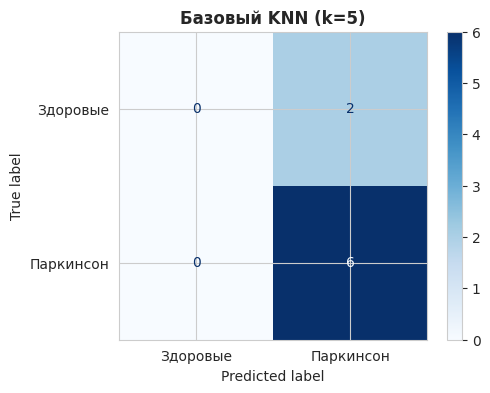

In [ ]:
cm_base = confusion_matrix(y_test, y_pred_base)
print(f"\nМатрица ошибок базовой модели:")
print(cm_base)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['Здоровые', 'Паркинсон'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Базовый KNN (k=5)', fontsize=12, fontweight='bold')
plt.show()


In [56]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sc, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший F1 (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Лучший F1 (CV): 0.8833


In [57]:
knn_best = grid_search.best_estimator_
y_pred_best = knn_best.predict(X_test_sc)
y_proba_best = knn_best.predict_proba(X_test_sc)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")

ROC-AUC: 1.0000
F1-score: 0.8571
Recall: 1.0000
Precision: 0.7500



Матрица ошибок оптимизированной модели:
[[0 2]
 [0 6]]


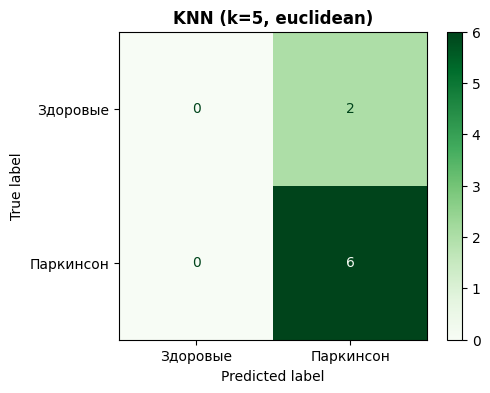

In [58]:
cm_best = confusion_matrix(y_test, y_pred_best)
print(f"\nМатрица ошибок оптимизированной модели:")
print(cm_best)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Здоровые', 'Паркинсон'])
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title(f'KNN (k={knn_best.n_neighbors}, {knn_best.metric})', fontsize=12, fontweight='bold')
plt.show()

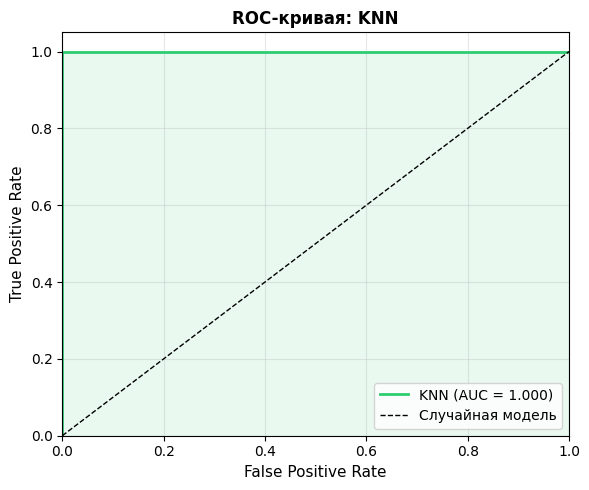

In [59]:
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#2ecc71', lw=2, label=f'KNN (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Случайная модель')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2ecc71')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC-кривая: KNN', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Подход без агрегации, сплиты по пациентам

In [167]:
def my_train_test_split(df, feature_cols, bucket=2, n_splits=5, random_state=RANDOM_STATE):
    X = df[feature_cols].values
    y = df['status'].values
    groups = df['patient_id'].values

    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    splits = list(sgkf.split(X, y, groups))
    train_idx, test_idx = splits[bucket]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups[train_idx]

    print(f"Записей в train: {len(X_train)} | больн: {y_train.sum()} ({y_train.mean():.1%})")
    print(f"Записей в test: {len(X_test)} | больн: {y_test.sum()} ({y_test.mean():.1%})")
    print(f"Пересечение пациентов: {len(set(groups[train_idx]) & set(groups[test_idx]))}")

    return X_train, X_test, y_train, y_test, groups_train

In [378]:
X_train_knn2, X_test_knn2, y_train_knn2, y_test_knn2, groups_train_knn2 = my_train_test_split(
    df, numeric_cols, n_splits=6, bucket=5, random_state=42
)

# Масштабирование
scaler_knn2 = RobustScaler()
X_train_knn2_sc = scaler_knn2.fit_transform(X_train_knn2)
X_test_knn2_sc = scaler_knn2.transform(X_test_knn2)

Записей в train: 165 | больн: 123 (74.5%)
Записей в test: 30 | больн: 24 (80.0%)
Пересечение пациентов: 0


In [379]:
knn_base2 = KNeighborsClassifier(n_neighbors=5)
knn_base2.fit(X_train_knn2_sc, y_train_knn2)

y_pred_base2 = knn_base2.predict(X_test_knn2_sc)
y_proba_base2 = knn_base2.predict_proba(X_test_knn2_sc)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test_knn2, y_proba_base2):.4f}")
print(f"F1-score: {f1_score(y_test_knn2, y_pred_base2):.4f}")
print(f"Recall: {recall_score(y_test_knn2, y_pred_base2):.4f}")
print(f"Precision: {precision_score(y_test_knn2, y_pred_base2):.4f}")

ROC-AUC: 0.8090
F1-score: 0.9057
Recall: 1.0000
Precision: 0.8276


In [392]:
# сохраняем параметры скейлера и модели
joblib.dump(scaler_knn2, 'scaler_knn.joblib')
joblib.dump(knn_base2, 'knn_base.joblib')

['knn_base.joblib']


Матрица ошибок базовой модели:
[[ 1  5]
 [ 0 24]]


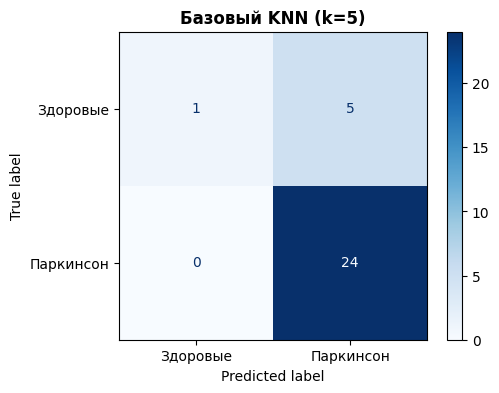

In [380]:
cm_base = confusion_matrix(y_test_knn2, y_pred_base2)
print(f"\nМатрица ошибок базовой модели:")
print(cm_base)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['Здоровые', 'Паркинсон'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Базовый KNN (k=5)', fontsize=12, fontweight='bold')
plt.show()

In [381]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan','minkowski']
}

cv_inner = StratifiedGroupKFold(n_splits=4, shuffle=True,
                                random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=cv_inner.split(X_train_knn2_sc, y_train_knn2, groups_train_knn2),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_knn2_sc, y_train_knn2)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший F1 (CV): {grid_search.best_score_:.4f}")

Fitting 4 folds for each of 30 candidates, totalling 120 fits

Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Лучший F1 (CV): 0.8573


In [382]:
knn_best = grid_search.best_estimator_
y_pred_best = knn_best.predict(X_test_knn2_sc)
y_proba_best = knn_best.predict_proba(X_test_knn2_sc)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test_knn2, y_proba_best):.4f}")
print(f"F1-score: {f1_score(y_test_knn2, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test_knn2, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test_knn2, y_pred_best):.4f}")

ROC-AUC: 0.8646
F1-score: 0.8627
Recall: 0.9167
Precision: 0.8148



Матрица ошибок оптимизированной модели:
[[ 1  5]
 [ 2 22]]


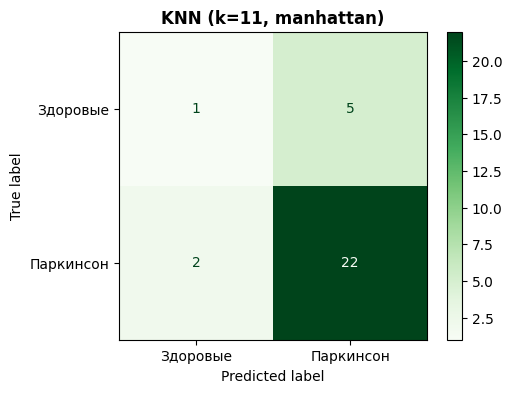

In [383]:
cm_best = confusion_matrix(y_test_knn2, y_pred_best)
print(f"\nМатрица ошибок оптимизированной модели:")
print(cm_best)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Здоровые', 'Паркинсон'])
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title(f'KNN (k={knn_best.n_neighbors}, {knn_best.metric})', fontsize=12, fontweight='bold')
plt.show()

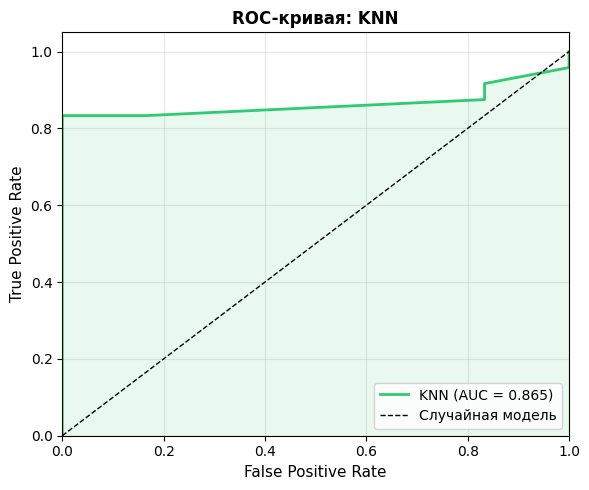

In [228]:
fpr, tpr, _ = roc_curve(y_test_knn2, y_proba_best)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#2ecc71', lw=2, label=f'KNN (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Случайная модель')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2ecc71')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC-кривая: KNN', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Итог (KNN)

---
Для данных с агрегацией по пациентам KNN показал F1-score 0.857, ROC-AUC 1.000, Recall 1.0 (найдены все больные) и Precision 0.750 (25% ложных срабатываний) с оптимальными параметрами n_neighbors=5, weights='uniform' и metric='euclidean'. Модель подойдет для скрининга (чувствительность 100%), но не для окончательной диагностики из-за низкой специфичности. Для улучшения требуется сбор дополнительных данных о здоровых пациентах.

Для данных без агрегации по пациентам KNN показал результаты хуже:
- Для деолтной модели F1-score 0.906, ROC-AUC 0.809, Recall 1.000 и Precision 0.828.
- После подбора гиперпараметров F1-score 0.863, ROC-AUC 0.864, Recall 0.917 и Precision 0.815 с оптимальными параметрами n_neighbors=11, weights='uniform' и metric='manhattan'.

---


# **3. SVM**

### Подбор гиперпараметров модели

В качестве модели предсказания используем SVC - метод опорных векторов для классификации.

Для начала посмотрим на результат предсказания модели с дефолтными параметрами.

### 1. Подход с агрегацией

In [106]:
X = patient_df.drop(columns=['patient_id', 'status'])
y = patient_df['status']

print(f'Размер X: {X.shape}')
print(f'Размер y: {y.shape}')

Размер X: (32, 22)
Размер y: (32,)


In [111]:
# Разделение
X_train_svm1, X_test_svm1, y_train_svm1, y_test_svm1 = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"Данные: {X_train_svm1.shape[0]} train, {X_test_svm1.shape[0]} test")
print(f"Признаков: {X_train_svm1.shape[1]}")

Данные: 24 train, 8 test
Признаков: 22


In [112]:
# Масштабирование
scaler_svm1 = RobustScaler()
X_train_svm_sc1 = scaler_svm1.fit_transform(X_train_svm1)
X_test_svm_sc1 = scaler_svm1.transform(X_test_svm1)

In [113]:
# Обучение базовой модели
svm_base1 = SVC(probability=True, random_state=RANDOM_STATE)
svm_base1.fit(X_train_svm_sc1, y_train_svm1)

y_proba_svm_base1 = svm_base1.predict_proba(X_test_svm_sc1)[:, 1]
y_pred_svm_base1 = svm_base1.predict(X_test_svm_sc1)

print(f"\nБазовый SVM ROC-AUC: {roc_auc_score(y_test_svm1, y_proba_svm_base1):.4f}\n")
print(classification_report(y_test_svm1, y_pred_svm_base1, digits=4))



Базовый SVM ROC-AUC: 0.9167
              precision    recall  f1-score   support

         0.0     1.0000    0.5000    0.6667         2
         1.0     0.8571    1.0000    0.9231         6

    accuracy                         0.8750         8
   macro avg     0.9286    0.7500    0.7949         8
weighted avg     0.8929    0.8750    0.8590         8



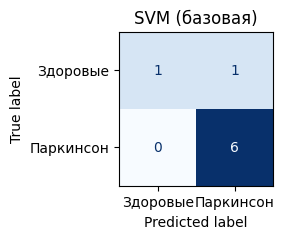

In [115]:
# Матрица ошибок
cm = confusion_matrix(y_test_svm1, y_pred_svm_base1)
fig, ax = plt.subplots(figsize=(4, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Здоровые', 'Паркинсон'])
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
plt.title('SVM (базовая)')
plt.show()

Теперь переберем различные гиперпараметры и выберем лучшую модель по метрике ROC-AUC.

- Главный гиперпараметр в методе опорных векторов - выбор ядерной функции. Ядерная функция переводит объекты из исходного пространства признаков в новое, где линейная гиперплоскость возможно лучше разделит данные. В зависимости от выбора ядра также можно выбрать гиперпараметры, связанные с ядерной функцией (например, степень полинома, параметр в функции сигмоиды).
- Параметр С отвечает за степень регуляризации - чувствительности к включению неправильных классификаций.
- Параметр class_weight включаем для всех моделей, он учитывает, что классы не сбалансирован: если None, то классы считаются одинаково встречающимися, если 'bakanced', то веса расчитываются обратно пропорционально частоте классов во входных данных.

In [116]:
param_grid = [
    {'kernel'       : ['linear'], # Линейное ядро
     'C'            : [0.001, 0.01, 0.1, 1, 10, 100],
     'class_weight' : [None, 'balanced']},

    {'kernel'       : ['rbf'], # RBF ядро
     'C'            : [0.01, 0.1, 1, 10, 100, 150],
     'gamma'        : ['scale', 'auto', 1e-3, 1e-2, 0.1],
     'class_weight' : [None, 'balanced']},

    {'kernel'       : ['poly'], # Полиномиальное ядро
     'C'            : [0.01, 0.1, 1, 10, 50],
     'degree'       : [2, 3, 4],
     'gamma'        : ['scale', 'auto'],
     'class_weight' : [None, 'balanced']},

    {'kernel'       : ['sigmoid'], # Сигмоидное ядро
     'C'            : [0.001, 0.01, 0.1, 1, 10, 20],
     'gamma'        : ['scale', 'auto'],
     'class_weight' : [None, 'balanced']}]

total = sum(np.prod([len(v) for v in d.values()])
                            for d in param_grid)
print(f"Всего комбинаций гиперпараметров: {int(total)}")

Всего комбинаций гиперпараметров: 156


In [118]:
# Перебор по сетке
grid_search = GridSearchCV(estimator=SVC(probability=True,
                                         random_state=RANDOM_STATE),
                           param_grid=param_grid,
                           cv=5,
                           scoring={'f1': 'f1', 'AUC': 'roc_auc'},
                           refit='f1',
                           n_jobs=-1,
                           verbose=1,)

# Обучение
grid_search.fit(X_train_svm_sc1, y_train_svm1)

best_svc1 = grid_search.best_estimator_

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_search.best_score_:.4f}")

# Оценка на тесте
y_pred_best1 = best_svc1.predict(X_test_svm_sc1)
y_proba_best1 = best_svc1.predict_proba(X_test_svm_sc1)[:, 1]

print(f"\nРЕЗУЛЬТАТЫ НА ТЕСТЕ:")
print(f"ROC-AUC: {roc_auc_score(y_test_svm1, y_proba_best1):.4f}")
print(f"F1: {f1_score(y_test_svm1, y_pred_best1):.4f}")

Fitting 5 folds for each of 156 candidates, totalling 780 fits

Лучшие параметры: {'C': 10, 'class_weight': None, 'gamma': 'auto', 'kernel': 'sigmoid'}
Лучший ROC-AUC (CV): 0.9492

РЕЗУЛЬТАТЫ НА ТЕСТЕ:
ROC-AUC: 0.9167
F1: 0.9091


Лучший результат достигается на модели со следующими гиперпараметрами:
- ядерная функция сигмоида $\frac{1}{1+e^{-x}}$;
- коэффициент влияния одного обучающего примера $\gamma$ = *auto*: рассчитывается динамически и зависит от от числа обучающих примеров;
- Коэффицент регуляризации C = 10, то есть модель сбалансирована между максимизацией зазора и допустимым числом ошибочных классификаций;
- class_weight = None, то есть веса классов не пересчитывались.

Посмотрим на предсказание лучшей модели:

In [119]:
y_pred_best1 = best_svc1.predict(X_test_svm_sc1)
print(classification_report(y_test_svm1, y_pred_best1, digits=4))

              precision    recall  f1-score   support

         0.0     0.6667    1.0000    0.8000         2
         1.0     1.0000    0.8333    0.9091         6

    accuracy                         0.8750         8
   macro avg     0.8333    0.9167    0.8545         8
weighted avg     0.9167    0.8750    0.8818         8



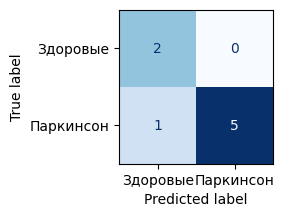

In [121]:
cm = confusion_matrix(y_test_svm1, y_pred_best1)
fig, ax = plt.subplots(figsize=(4, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Здоровые', 'Паркинсон'])
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)

plt.show()

SVM на агрегированных данных показывает не очень высокую чувствительность к больным (recall=0.83) и низкую специфичность к здоровым (precision=0.67 для класса 0). Это делает модель не самым лучшим вариантом для клинического применения в текущем виде. Далее рассмотрим разбиение данных с помощью функции my_train_test_split, которая использует StratifiedGroupKFold.

### 2. Подход без агрегации, сплиты по пациентам

Используем StratifiedGroupKFold для разбиения данных по фолдам со стратификацией по наличию болезни, а также без пересечения по пациентам.

Разбиение на тестовую и тренировочную сделаем в соотношении 20:80, то есть все данные делим на 5 фолдов.

In [123]:
df_raw = pd.read_csv('parkinsons.data')
df_raw['patient_id'] = df_raw['name'].str.split('_').str[2]
feature_cols = [c for c in df_raw.columns if c not in ('name', 'status', 'patient_id')]

In [124]:
X_train_svm, X_test_svm, y_train_svm, y_test_svm, groups_train_svm = my_train_test_split(
    df_raw, feature_cols, n_splits=5
)

# Масштабирование
scaler_svm = RobustScaler()
X_train_svm_sc = scaler_svm.fit_transform(X_train_svm)
X_test_svm_sc = scaler_svm.transform(X_test_svm)

Записей в train: 158 | больн: 116 (73.4%)
Записей в test: 37 | больн: 31 (83.8%)
Пересечение пациентов: 0


In [125]:
# Обучение базовой модели
svm_base = SVC(probability=True, random_state=RANDOM_STATE)
svm_base.fit(X_train_svm_sc, y_train_svm)

y_proba_svm_base = svm_base.predict_proba(X_test_svm_sc)[:, 1]
y_pred_svm_base = svm_base.predict(X_test_svm_sc)

print(f"\nБазовый SVM ROC-AUC: {roc_auc_score(y_test_svm, y_proba_svm_base):.4f}")
print(classification_report(y_test_svm, y_pred_svm_base, digits=4))



Базовый SVM ROC-AUC: 0.8441
              precision    recall  f1-score   support

           0     0.5000    0.6667    0.5714         6
           1     0.9310    0.8710    0.9000        31

    accuracy                         0.8378        37
   macro avg     0.7155    0.7688    0.7357        37
weighted avg     0.8611    0.8378    0.8467        37



In [126]:
print("Распределение меток в предсказании:")
pd.Series(y_pred_svm_base).value_counts()

Распределение меток в предсказании:


,count
1,29
0,8


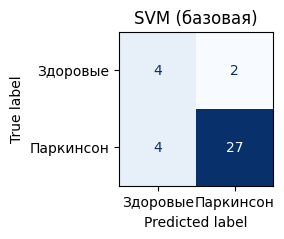

In [127]:
# Матрица ошибок
cm = confusion_matrix(y_test_svm, y_pred_svm_base)
fig, ax = plt.subplots(figsize=(4, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Здоровые', 'Паркинсон'])
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
plt.title('SVM (базовая)')
plt.show()

Теперь переберем различные гиперпараметры и выберем лучшую модель по метрике ROC-AUC.

- Главный гиперпараметр в методе опорных векторов - выбор ядерной функции. Ядерная функция переводит объекты из исходного пространства признаков в новое, где линейная гиперплоскость возможно лучше разделит данные. В зависимости от выбора ядра также можно выбрать гиперпараметры, связанные с ядерной функцией (например, степень полинома, параметр в функции сигмоиды).
- Параметр С отвечает за степень регуляризации - чувствительности к включению неправильных классификаций.
- Параметр class_weight включаем для всех моделей, он учитывает, что классы не сбалансирован: если None, то классы считаются одинаково встречающимися, если 'bakanced', то веса расчитываются обратно пропорционально частоте классов во входных данных.

In [128]:
cv_inner = StratifiedGroupKFold(n_splits=4, shuffle=True,
                                random_state=RANDOM_STATE)

# Пер
grid_search = GridSearchCV(estimator=SVC(probability=True,
                                         random_state=RANDOM_STATE),
                           param_grid=param_grid,
                           cv=cv_inner.split(X_train_svm_sc, y_train_svm, groups_train_svm),
                           scoring={'f1': 'f1', 'AUC': 'roc_auc'},
                           refit='f1',
                           n_jobs=-1,
                           verbose=1,)

# Обучение
grid_search.fit(X_train_svm_sc, y_train_svm)

best_svc = grid_search.best_estimator_

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_search.best_score_:.4f}")

# Оценка на тесте
y_pred_best = best_svc.predict(X_test_svm_sc)
y_proba_best = best_svc.predict_proba(X_test_svm_sc)[:, 1]

print(f"\nРЕЗУЛЬТАТЫ НА ТЕСТЕ:")
print(f"ROC-AUC: {roc_auc_score(y_test_svm, y_proba_best):.4f}")
print(f"F1: {f1_score(y_test_svm, y_pred_best):.4f}")

Fitting 4 folds for each of 156 candidates, totalling 624 fits

Лучшие параметры: {'C': 1, 'class_weight': None, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
Лучший ROC-AUC (CV): 0.8696

РЕЗУЛЬТАТЫ НА ТЕСТЕ:
ROC-AUC: 0.8925
F1: 0.9524


Лучший результат достигается на модели со следующими гиперпараметрами:
- ядерная функция полиномиальная $(\gamma<x, x'> + r)^d$;
- со степенью d = 2;
- коэффициент влияния одного обучающего примера $\gamma$ = *scale*: рассчитывается динамически и зависит от от числа обучающих примеров и их дисперсии;
- Коэффицент регуляризации C = 1, то есть модель сбалансирована между максимизацией зазора и допустимым числом ошибочных классификаций;
- class_weight = None, то есть веса классов не пересчитывались.

Посмотрим на предсказание лучшей модели:

In [129]:
y_pred_best = best_svc.predict(X_test_svm_sc)
print(classification_report(y_test_svm, y_pred_best, digits=4))

              precision    recall  f1-score   support

           0     0.8000    0.6667    0.7273         6
           1     0.9375    0.9677    0.9524        31

    accuracy                         0.9189        37
   macro avg     0.8688    0.8172    0.8398        37
weighted avg     0.9152    0.9189    0.9159        37



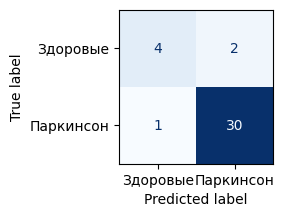

In [130]:
cm = confusion_matrix(y_test_svm, y_pred_best)  # <- y_test_svm из my_train_test_split
fig, ax = plt.subplots(figsize=(4, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Здоровые', 'Паркинсон'])
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)

plt.show()

In [154]:
# сохраняем параметры скейлера и модели
joblib.dump(scaler_svm, 'scaler_svm.joblib')
joblib.dump(best_svc, 'best_svc.joblib')

['best_svc.joblib']

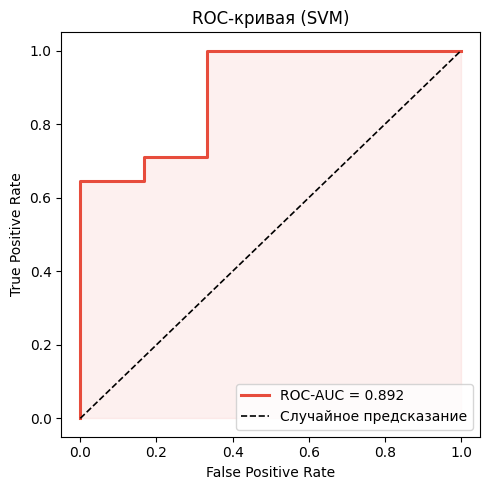

In [131]:
y_proba = best_svc.predict_proba(X_test_svm_sc)[:, 1]

fig, axes = plt.subplots(figsize=(5, 5))

fpr, tpr, _ = roc_curve(y_test_svm, y_proba)
roc_val = auc(fpr, tpr)

axes.plot(fpr, tpr, color='#e74c3c', lw=2.2,
          label=f'ROC-AUC = {roc_val:.3f}')
axes.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Случайное предсказание')
axes.fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')
axes.set_xlabel('False Positive Rate')
axes.set_ylabel('True Positive Rate')
axes.set_title('ROC-кривая (SVM)', fontsize=12)
axes.legend(loc='lower right')

plt.tight_layout()
plt.show()

После подбора лучших гиперпараметров мы видим, что
- ROC-AUC увеличился на 5% с 84% до 89%,
- recall увеличился почти на 10% с 87% до 97%

Удалось улучшить предсказание модели - теперь она реже совершают ошибку второго рода, то есть помечает объект с болезнью как здоровый. При этом число ошибок первого рода, то есть пометка здорового объекта как больного, не изменилось.

После подбора лучших гиперпараметров мы видим, что
- ROC-AUC увеличился на 5% с 84% до 89%,
- recall увеличился почти на 10% с 87% до 97%

Удалось улучшить предсказание модели - теперь она реже совершают ошибку второго рода, то есть помечает объект с болезнью как здоровый. При этом число ошибок первого рода, то есть пометка здорового объекта как больного, не изменилось.

**SHAP (SHapley Additive exPlanations)** — метод из теории кооперативных игр.  
Для каждого наблюдения он показывает, насколько каждый признак сдвинул предсказание относительно среднего по датасету.

Для SVC с нелинейным ядром используется *KernelExplainer* — он работает с любой
моделью как с чёрным ящиком, оценивая вклад признаков через подстановку фоновых значений.

В качестве фона берём *shap.kmeans* — сжатое представление train-выборки (50 кластеров).

In [ ]:
shap.initjs()

n_clusters = min(8, X_train_svm_sc.shape[0] // 2)
print(f"Используем {n_clusters} кластеров для фонового датасета")

background = shap.kmeans(X_train_svm_sc, n_clusters)

# KernelExplainer через predict_proba
explainer = shap.KernelExplainer(best_svc.predict_proba, background)
shap_values = explainer.shap_values(X_test_svm_sc, nsamples=100)  # <- X_test_svm_sc

# Берём значения для класса 1 (больные)
if isinstance(shap_values, list):
    sv_sick = shap_values[1]
else:
    sv_sick = shap_values

print(f"SHAP values shape : {sv_sick.shape}")
print(f"Base value        : {explainer.expected_value[1]:.4f}")


Используем 8 кластеров для фонового датасета


  0%|          | 0/37 [00:00<?, ?it/s]

SHAP values shape : (37, 22, 2)
Base value        : 0.7701


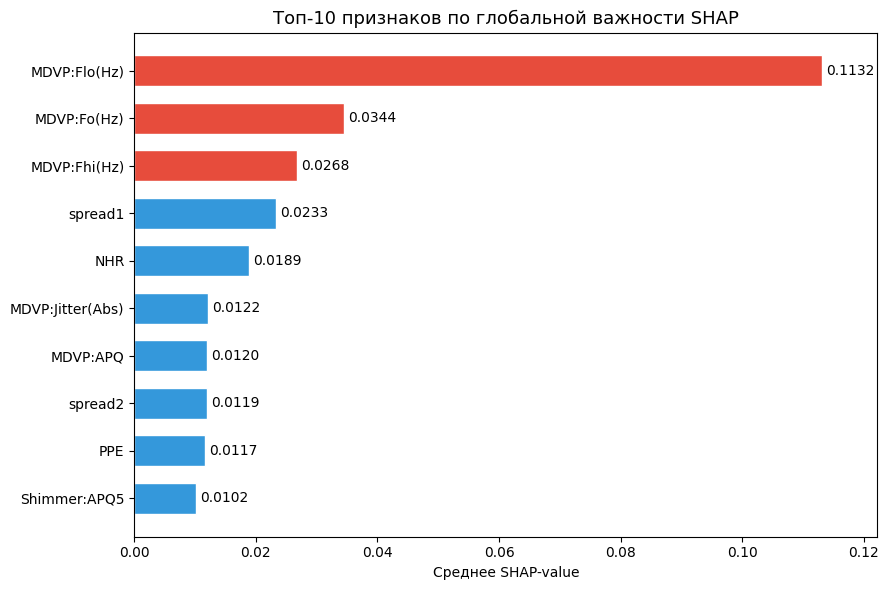

In [ ]:
shap_importance = np.abs(sv_sick).mean(axis=0).mean(axis=1) if sv_sick.ndim == 3 else np.abs(sv_sick).mean(axis=0)

mean_abs_shap = pd.Series(shap_importance, index=feature_cols).sort_values(ascending=False)

top_n = 10
top = mean_abs_shap.head(top_n).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if v >= top.values[-3] else '#3498db' for v in top.values]
bars = ax.barh(top.index, top.values, color=colors, edgecolor='white', height=0.65)
ax.bar_label(bars, padding=3, fmt='{:.4f}')
ax.set_xlabel('Среднее SHAP-value')
ax.set_title(f'Топ-{top_n} признаков по глобальной важности SHAP', fontsize=13)
ax.set_xlim(0, max(top.values) * 1.08)
plt.tight_layout()
plt.show()


### Итог (SVM)

---



Для дефолтной модели SVC, обученной на агрегированных на уровне пациентов данных, имеем следующие метрики качества:
| ROC-AUC | recall | precision | f1 |
| -------- | -------- | -------- | -------- |
| 0.917  | 1.000  | 0.857  | 0.909  |

После подбора гиперпараметров получаем метрики:
| ROC-AUC | recall | precision | f1 |
| -------- | -------- | -------- | -------- |
| 0.917  | 0.833  | 1.000  | 0.909 |

Обучим модели по второму подходу: делим со стратификацией по таргету (так как классы не сбалансированы) и с учетом того, что на одного пациента приходится несксолько обучающих примеров - данные одного пациента не должны разделяться между трейном и тестом.

Обучение модели классификации по методу опорных векторов (SVC) с дефолтными параметрами дало точности
| ROC-AUC | recall | precision | f1 |
| -------- | -------- | -------- | -------- |
| 0.844  | 0.871  | 0.931  | 0.900  |

После перебора гиперпараметров модели удалось улучшить предсказание. Для модели с полиномиальным ядром степени 2 и коэффициентом регуляризации C = 1 удалось добиться
| ROC-AUC | recall | precision | f1 |
| -------- | -------- | -------- | -------- |
| 0.892  | 0.968  | 0.938  | 0.952  |

Выросли все метрики, а главное метрика recall увеличилась почти на 10%. Близость этой метрики к 100% показывает малую вероятность ошибки 2-го рода, совершение которой при прдесказании болезни критически важно.

Анализ важности признаков для лучшей модели показал, что в среднем изменение почти на 10% дает признак *MDVP:Flo(Hz)*. Остальные признаки вносят вклад ~3% и менее. В топ-3 по важности вошли признаки отвечающие за частоту основного тона (Fo), затем идут показатели шумовых компонент голоса и нелинейной динамики/сложности сигнала.

# **4. Decision tree**

### 1. Подход с агрегацией

In [394]:
# Заново определим трейн и тест выборки
X = patient_df.drop(columns=['patient_id', 'status'])
y = patient_df['status'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [395]:
# обучение модели
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [396]:
# предсказание модели
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

In [399]:
# сохраняем параметры скейлера и модели
joblib.dump(dt_model, 'dt_model.joblib')

['dt_model.joblib']

#### Оценка модели

In [397]:
# отчет классификации
print(classification_report(y_test, y_pred_dt, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.86      1.00      0.92         6

    accuracy                           0.88         8
   macro avg       0.93      0.75      0.79         8
weighted avg       0.89      0.88      0.86         8



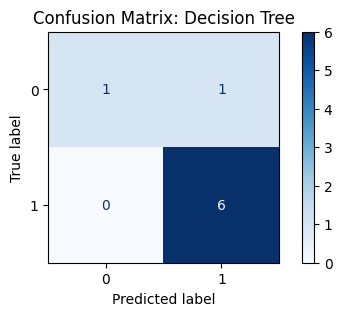

In [398]:
# матрица ошибок
fig, ax = plt.subplots(figsize=(6, 3))
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=dt_model.classes_
)

disp.plot(cmap='Blues', ax=ax)

plt.title('Confusion Matrix: Decision Tree')
plt.show()

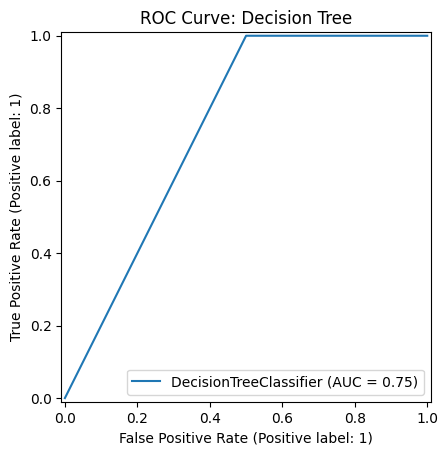

In [146]:
# ROC-кривая
RocCurveDisplay.from_estimator(dt_model, X_test, y_test)
plt.title('ROC Curve: Decision Tree')
plt.show()

Перепишем агрегацию с std

In [149]:
numeric_cols = df.drop(columns=['name', 'status', 'patient_id']).columns

df_features_patient = (
    df
    .groupby('patient_id')[numeric_cols]
    .agg(['mean', 'std'])  #  добавляем std
)

df_features_patient.columns = [
    f'{feature}_{stat}'
    for feature, stat in df_features_patient.columns
]

df_features_patient = df_features_patient.reset_index()
df_status_patient = df[['patient_id', 'status']].drop_duplicates()

df_patient = df_features_patient.merge(df_status_patient, on='patient_id', how='left')
df_patient = df_patient.fillna(0)

print(f"После агрегации: {df_patient.shape[0]} пациентов, {df_patient.shape[1]} признаков")
print(f"Из них признаков: {df_patient.shape[1] - 2} (средние + стандартные отклонения)")

# Признаки и цель
X = df_patient.drop(columns=['patient_id', 'status'])
y = df_patient['status']

print(f"X shape: {X.shape}")

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Обучение дерева (без масштабирования)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Оценка
y_proba = dt_model.predict_proba(X_test)[:, 1]
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"\n{classification_report(y_test, y_pred_dt,
                                 zero_division=0, digits=4)}")


После агрегации: 32 пациентов, 46 признаков
Из них признаков: 44 (средние + стандартные отклонения)
X shape: (32, 44)

ROC-AUC: 0.7500

              precision    recall  f1-score   support

           0     1.0000    0.5000    0.6667         2
           1     0.8571    1.0000    0.9231         6

    accuracy                         0.8750         8
   macro avg     0.9286    0.7500    0.7949         8
weighted avg     0.8929    0.8750    0.8590         8



In [ ]:
# таблица важности признаков
feature_importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance_dt.head(5).round(4))

              Feature  Importance
36       spread1_mean      0.6049
11       MDVP:RAP_std      0.2099
1     MDVP:Fo(Hz)_std      0.1852
2   MDVP:Fhi(Hz)_mean      0.0000
3    MDVP:Fhi(Hz)_std      0.0000


In [ ]:
df_features_patient = (
    df
    .groupby('patient_id')[numeric_cols]
    .agg(['mean', 'std'])
)
df_features_patient.columns = [
    f'{feature}_{stat}'
    for feature, stat in df_features_patient.columns
]

df_features_patient = df_features_patient.reset_index()
df_status_patient = df[['patient_id', 'status']].drop_duplicates()

df_patient = df_features_patient.merge(df_status_patient, on='patient_id', how='left')
df_patient = df_patient.fillna(0)

X = df_patient.drop(columns=['patient_id', 'status'])
y = df_patient['status']


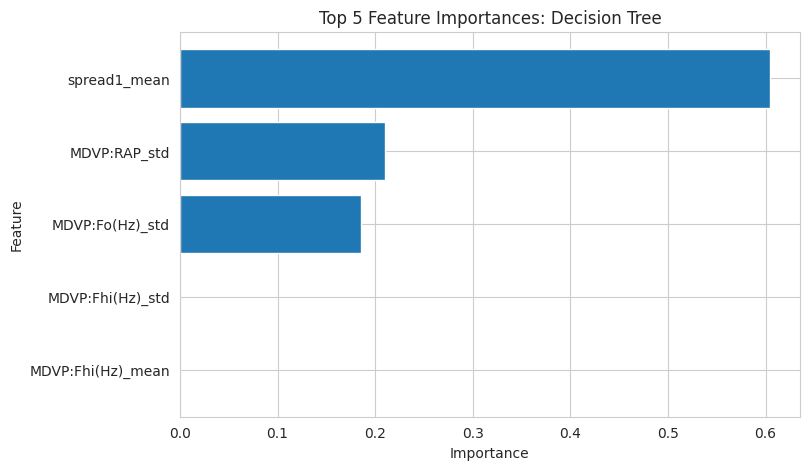

In [ ]:
# график важности признаков
top_features_dt = feature_importance_dt.head().sort_values('Importance')

plt.figure(figsize=(8, 5))

plt.barh(top_features_dt['Feature'], top_features_dt['Importance'])

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 5 Feature Importances: Decision Tree')

plt.show()

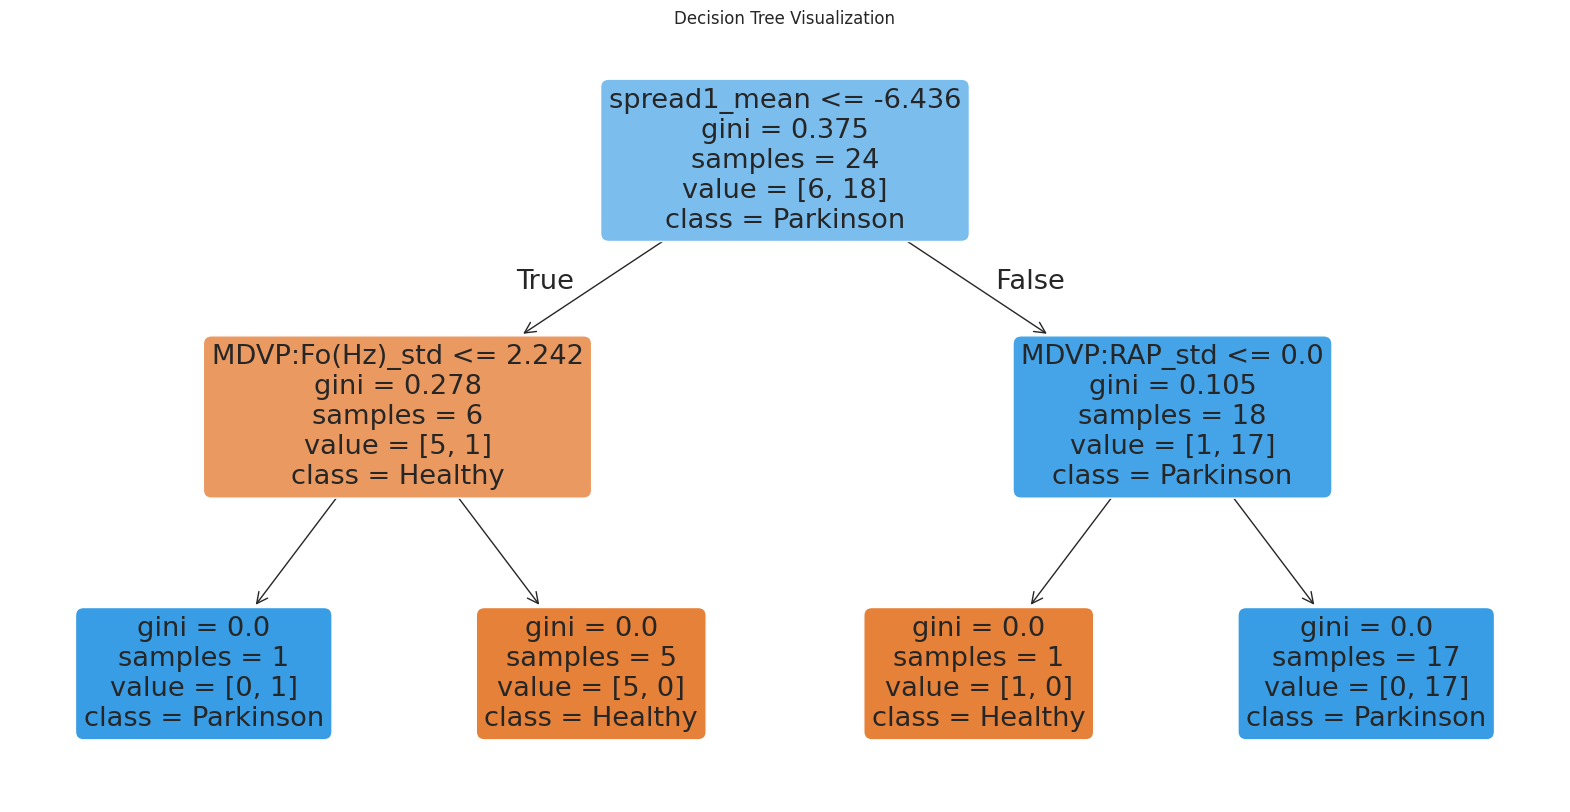

In [ ]:
# визуализация дерева решений
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=['Healthy', 'Parkinson'],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title('Decision Tree Visualization')
plt.show()

### 2. Подход без агрегации, сплит по пациентам

In [236]:
# Разделим выборки по новому правилу
X_train_dt2, X_test_dt2, y_train_dt2, y_test_dt2, groups_train_dt2 = my_train_test_split(
    df_raw, feature_cols, n_splits=5, bucket=3, random_state=42)

Записей в train: 153 | больн: 111 (72.5%)
Записей в test: 42 | больн: 36 (85.7%)
Пересечение пациентов: 0


In [237]:
# обучение модели
dt_model2 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model2.fit(X_train_dt2, y_train_dt2)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [238]:
# предсказание модели
y_pred_dt2 = dt_model2.predict(X_test_dt2)
y_proba_dt2 = dt_model2.predict_proba(X_test_dt2)[:, 1]

In [239]:
# отчет классификации
print(classification_report(y_test_dt2, y_pred_dt2,
                            zero_division=0, digits=4))

              precision    recall  f1-score   support

           0     0.6000    0.5000    0.5455         6
           1     0.9189    0.9444    0.9315        36

    accuracy                         0.8810        42
   macro avg     0.7595    0.7222    0.7385        42
weighted avg     0.8734    0.8810    0.8764        42



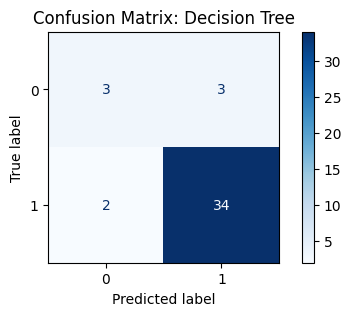

In [240]:
# матрица ошибок
fig, ax = plt.subplots(figsize=(6, 3))
cm_dt = confusion_matrix(y_test_dt2, y_pred_dt2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=dt_model.classes_
)

disp.plot(cmap='Blues', ax=ax)

plt.title('Confusion Matrix: Decision Tree')
plt.show()

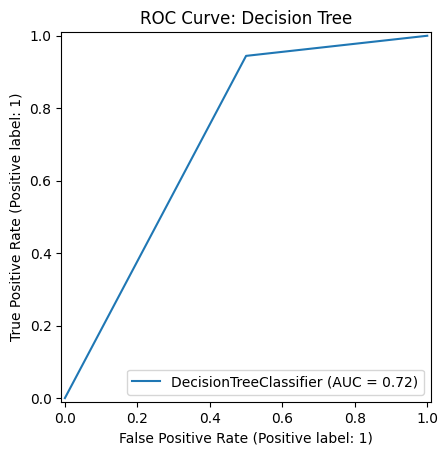

In [242]:
# ROC-кривая
RocCurveDisplay.from_estimator(dt_model2, X_test_dt2, y_test_dt2)
plt.title('ROC Curve: Decision Tree')
plt.show()

# **5. RandomForest**

### 1. Подход с агрегацией (mean + std)

In [243]:
# Заново определим трейн и тест выборки
X = patient_df.drop(columns=['patient_id', 'status'])
y = patient_df['status'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

In [244]:
# обучение модели
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [245]:
# предсказание модели
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

Оценка модели

In [246]:
# отчет классификации
print(classification_report(y_test, y_pred_rf, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.86      1.00      0.92         6

    accuracy                           0.88         8
   macro avg       0.93      0.75      0.79         8
weighted avg       0.89      0.88      0.86         8



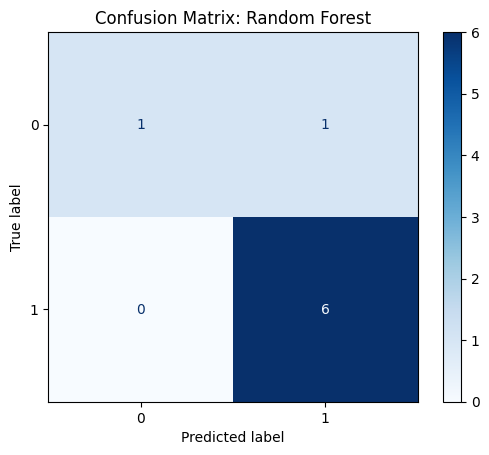

In [247]:
# матрица ошибок
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf_model.classes_
)

disp.plot(cmap='Blues')

plt.title('Confusion Matrix: Random Forest')
plt.show()

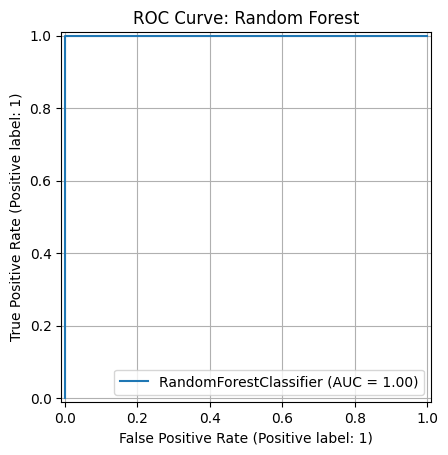

In [250]:
# ROC-кривая
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.grid()
plt.title('ROC Curve: Random Forest')
plt.show()

In [251]:
# таблица важности признаков
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance_rf.head(10)

,Feature,Importance
18,spread1,0.1407
21,PPE,0.1088
5,MDVP:RAP,0.0657
19,spread2,0.0656
16,RPDE,0.0642
12,MDVP:APQ,0.0636
2,MDVP:Flo(Hz),0.0634
14,NHR,0.0606
20,D2,0.0467
7,Jitter:DDP,0.0461


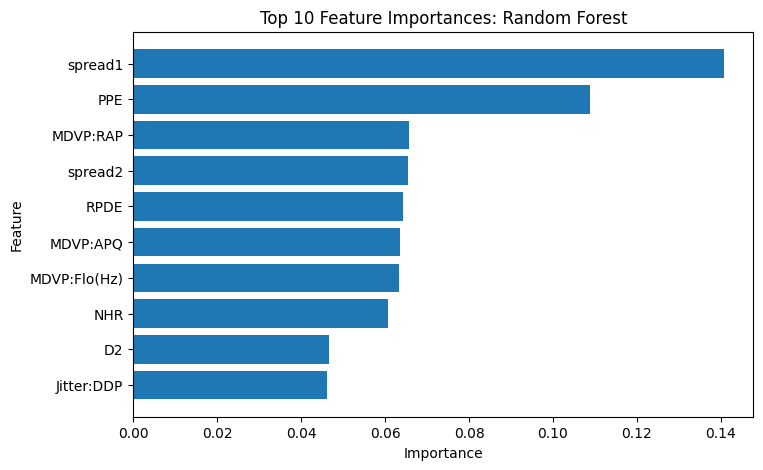

In [254]:
# график важности признаков
top_features_rf = feature_importance_rf.head(10).sort_values('Importance')

plt.figure(figsize=(8, 5))

plt.barh(top_features_rf['Feature'], top_features_rf['Importance'])

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances: Random Forest')

plt.show()

### 2. Подход без агрегации, сплит по пациентам

In [291]:
# Разделим выборки по новому правилу
X_train_rf2, X_test_rf2, y_train_rf2, y_test_rf2, groups_train_rf2 = my_train_test_split(
    df_raw, feature_cols, n_splits=5, bucket=3, random_state=42)

Записей в train: 153 | больн: 111 (72.5%)
Записей в test: 42 | больн: 36 (85.7%)
Пересечение пациентов: 0


In [292]:
# обучение модели
rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model2.fit(X_train_rf2, y_train_rf2)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [400]:
# сохраняем параметры скейлера и модели
joblib.dump(rf_model2, 'rf_model.joblib')

['rf_model.joblib']

In [293]:
# предсказание модели
y_pred_rf2 = rf_model2.predict(X_test_rf2)
y_proba_rf2 = rf_model2.predict_proba(X_test_rf2)[:, 1]

In [294]:
# отчет классификации
print(classification_report(y_test_rf2, y_pred_rf2,
                            zero_division=0, digits=4))

              precision    recall  f1-score   support

           0     0.8571    1.0000    0.9231         6
           1     1.0000    0.9722    0.9859        36

    accuracy                         0.9762        42
   macro avg     0.9286    0.9861    0.9545        42
weighted avg     0.9796    0.9762    0.9769        42



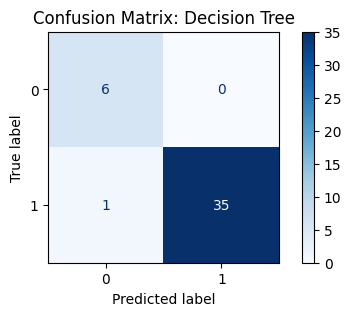

In [295]:
# матрица ошибок
fig, ax = plt.subplots(figsize=(6, 3))
cm_dt = confusion_matrix(y_test_rf2, y_pred_rf2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=dt_model.classes_
)

disp.plot(cmap='Blues', ax=ax)

plt.title('Confusion Matrix: Decision Tree')
plt.show()

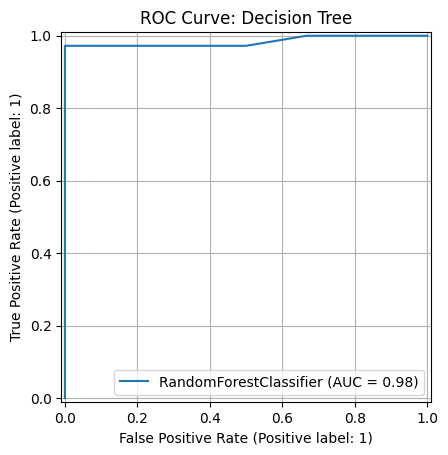

In [296]:
# ROC-кривая
RocCurveDisplay.from_estimator(rf_model2, X_test_rf2, y_test_rf2)
plt.grid()
plt.title('ROC Curve: Decision Tree')
plt.show()

### Сравнение моделей Decision Tree и Random Forest

In [299]:
# сводная таблица метрик
comparison_models = pd.DataFrame({
    'Model': [
        'Decision Tree with agg',
        'Decision Tree without agg',
        'Random Forest with agg',
        'Random Forest without agg'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test_dt2, y_pred_dt2),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test_rf2, y_test_rf2)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test_dt2, y_pred_dt2, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test_rf2, y_pred_rf2, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test_dt2, y_pred_dt2, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test_rf2, y_pred_rf2, zero_division=0)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test_dt2, y_pred_dt2, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test_rf2, y_pred_rf2, zero_division=0)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test_dt2, y_proba_dt2),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test_rf2, y_proba_rf2)
    ]
})

comparison_models.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree with agg,0.8750,0.8570,1.0000,0.9230,0.7500
1,Decision Tree without agg,0.8810,0.9190,0.9440,0.9320,0.7220
2,Random Forest with agg,0.8750,0.8570,1.0000,0.9230,1.0000
3,Random Forest without agg,1.0000,1.0000,0.9720,0.9860,0.9840


### Итог(Random forest, Decision Tree):

---

В ходе работы были построены модели дерева решений и случайного леса для классификации пациентов по акустическим характеристикам голоса. Применялись два подхода обработки данных перед разделением на учебные выборки: 1) данные были агрегированы до уровня пациентов, что позволило снизить зависимость между наблюдениями, 2) без агрегации на уровне пациентов, но с разделением таким образом, что в трейн и тест не может попасть один и тот же пациент, что позволило сохранить исходный объем выборки.

Модели без агрегации показали одинаковые значения Accuracy, Precision, Recall и F1-score на тестовой выборке для двух вариантов агрегации: среднее и среднее с стандартным отклонением. При этом случайный лес продемонстрировал более высокое значение ROC-AUC, что свидетельствует о лучшем разделении классов на уровне вероятностных прогнозов. Следовательно, среди рассмотренных двух моделей случайный лес можно считать наиболее предпочтительным для решения данной задачи. Однако результаты следует интерпретировать с осторожностью из-за небольшого объема выборки после агрегации данных.

При этом модели без агрегации показали лучшие результаты по сравнению с моделями с агрегацией. Лучшие результаты достигаются для модели Random Forest without agg, почти все показатели близки к 1.


# **6. XGBoost**

In [300]:
print(f"Датасет: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Уникальных пациентов: {df['patient_id'].nunique()}")
print("Распределение классов:")
print(df['status'].value_counts())

Датасет: 195 строк, 25 столбцов
Уникальных пациентов: 32
Распределение классов:
status
1    147
0     48
Name: count, dtype: int64


In [301]:
feature_cols = [col for col in df.columns if col not in ['name', 'status', 'patient_id']]
X = df[feature_cols].copy()
y = df['status'].copy()
groups = df['patient_id'].copy()
print(f"Использовано признаков: {len(feature_cols)}")

Использовано признаков: 22


In [305]:
razbivka = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
train_idx, test_idx = next(razbivka.split(X, y, groups=groups))

In [306]:
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

In [307]:
print("Разбиение по пациентам")
print(f"трейн {len(X_train)} записей, {groups_train.nunique()} пациентов")
print(f"тест   {len(X_test)} записей, {groups_test.nunique()} пациентов")
print(f"трейн статус {y_train.value_counts().to_dict()}")
print(f"тест статус  {y_test.value_counts().to_dict()}")

Разбиение по пациентам
трейн 98 записей, 16 пациентов
тест   97 записей, 16 пациентов
трейн статус {1: 68, 0: 30}
тест статус  {1: 79, 0: 18}


Обработаю выбросы - fit только на трейн

In [315]:
class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None
        self.columns_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = X.columns
        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1
        self.lower_bounds_ = q1 - self.factor * iqr
        self.upper_bounds_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X.columns = self.columns_
        for col in self.columns_:
          X[col] = X[col].clip(self.lower_bounds_[col], self.upper_bounds_[col])
          return X

Таким образом, подитожу: перед обучением данные нашего датасета были очищены от выбросов с помощью метода ограничения значений по межквартильному размаху - IQR. И проведено деление на трейн и тест таким образом, чтобы записи одного и того же пациента не попали одновременно и в трейн, и в тест.Все эти действия должны повысить качество и надежность модели.

Для построения  модели классификации пациентов с болезнью Паркинсона мне достался Gradient Boosting. XGBoost замечательно работает с табличными данными, устойчиво справляется с коррелированными признаками, также отмечу что он автоматически выявляет важные признаки, что повышает качество предсказаний. В качестве базовых сравниваемых моделей будет использована наивная классификация(предсказание класса большинства) и логистическая регрессия с маштабированием признаков.

Также замечу, что целевой метрикой мною была выбрана ROC-AUC. Это метрика бинарной классификации, она подходит хорошо при сбалансированных классах. Еще раз акцентирую внимание: я не удаляла коррелированные признаки, поскольку XGBoost хорошо устойчив к корреляциям.

In [316]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Наивный прогноз (класс большинства):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_dummy):.4f}")

Наивный прогноз (класс большинства):
Accuracy: 0.8144
F1-score: 0.8977


Далее, сделаю Логистическую регрессию (бейзлайн).

In [317]:
lr_pipe = Pipeline([
    ('capper', IQRCapper()),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_proba_lr = lr_pipe.predict_proba(X_test)[:, 1]

In [318]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.4f}")

Accuracy:  0.7732
Precision: 0.8519
Recall:    0.8734
F1-score:  0.8625
ROC-AUC:   0.7257


Продолжу анализ с помощью XGBoost.

Градиентный спуск (базовый).

In [319]:
xgb_base_pipe = Pipeline([
    ('capper', IQRCapper()),
    ('model', xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_base_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_base_pipe.predict(X_test)
y_proba_xgb = xgb_base_pipe.predict_proba(X_test)[:, 1]

In [320]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_xgb):.4f}")

Accuracy:  0.8351
Precision: 0.8316
Recall:    1.0000
F1-score:  0.9080
ROC-AUC:   0.7409


Подберу гиперпараметры к этой модели - только внутри трейн и с учетом групп. Фолдов сделаю все-таки 5, а не 10, поскольку модель сама по себе сложная, и немножко уменьшу количество параметров, очень уж медленно у меня все считает.

In [321]:
group_cv = GroupShuffleSplit(n_splits=5, test_size=0.25, random_state=42)

In [322]:
param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [3],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [1.0],
    'model__min_child_weight': [1]
}

In [323]:
xgb_tune_pipe = Pipeline([
    ('capper', IQRCapper()),
    ('model', xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

In [325]:
grid_search = GridSearchCV(
    estimator=xgb_tune_pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=group_cv.split(X_train, y_train, groups=groups_train),
    n_jobs=1,
    verbose=1
)

In [326]:
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=<generator object BaseShuffleSplit.split at 0x78795de21940>,
             estimator=Pipeline(steps=[('capper', IQRCapper()),
                                       ('model',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='logloss',
                                                      feature_t...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=1,
             param_grid={'model__colsample_bytree': [1.0],
                         'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [3],
                         'model__min_child_weight': [1],
                         'model__n_estimators': [50, 100],
                         'model__subsample': [0.8, 1.0]},
             scoring='f1', verbose=1)

In [328]:
print(f"\nлучшие параметры grid_search")
print(f"лучший F1 на CV {grid_search.best_score_:.4f}")


лучшие параметры grid_search
лучший F1 на CV 0.7737


Посчитаю лучшую модель на тесте.

In [329]:
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

In [401]:
# сохраняем параметры скейлера и модели
joblib.dump(best_xgb, 'xgb_model.joblib')

['xgb_model.joblib']

In [330]:
print(f"Accuracy - {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision - {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall  - {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-score - {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC -{roc_auc_score(y_test, y_proba_best):.4f}")

Accuracy - 0.8351
Precision - 0.8316
Recall  - 1.0000
F1-score-  0.9080
ROC-AUC -0.7461


Далее, сделаю сводную таблицу результатов.

In [331]:
results = pd.DataFrame({
    'Model': ['Dummy', 'Logistic Regression', 'XGBoost base', 'XGBoost tuned'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best)
    ],

    'Precision': [
        precision_score(y_test, y_pred_dummy, zero_division=0),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_best)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dummy),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_best)
    ],

    'F1': [
        f1_score(y_test, y_pred_dummy),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_best)
    ],

    'ROC-AUC': [
        np.nan,
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_best)
    ]
})
results.sort_values('ROC-AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,XGBoost tuned,0.8351,0.8316,1.0000,0.9080,0.7461
2,XGBoost base,0.8351,0.8316,1.0000,0.9080,0.7409
1,Logistic Regression,0.7732,0.8519,0.8734,0.8625,0.7257
0,Dummy,0.8144,0.8144,1.0000,0.8977,NaN


Отмечу, что настройка гиперпараметров для XGBoost улучшила показатели модели.

Метамодель на данном этапе не применялась, поскольку задача на данной этапе, как я поняла, это оценка производительности отдельных моделей, а использование ансамблей будет возможно в дальнейшем при наличии сильных базовых моделей.

Далее, проанализирую и проинтерпретирую порог (в части медицинского контекста).

In [332]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

best_f1_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_f1_idx]

target_recall = 0.9
valid = np.where(recalls[:-1] >= target_recall)[0]
if len(valid) > 0:
    best_threshold_recall = thresholds[valid[0]]
    precision_at_recall = precisions[valid[0]]
else:
    best_threshold_recall = 0.5
    precision_at_recall = 0

print("Оптимизация порога:")
print(f"Порог по умолчанию (0.5): Recall = {recall_score(y_test, y_pred_best):.4f}")
print(f"Оптимальный порог по F1: {best_threshold_f1:.3f} (F1 = {f1_scores[best_f1_idx]:.4f})")
print(f"Порог для Recall ≥ 0.9: {best_threshold_recall:.3f} (Precision = {precision_at_recall:.4f})")

y_pred_safe = (y_proba_best >= best_threshold_recall).astype(int)
print(f"\nПри пороге {best_threshold_recall:.3f}:")
print(f"Recall = {recall_score(y_test, y_pred_safe):.4f} (пропускаем только {(1-recall_score(y_test, y_pred_safe))*100:.1f}% больных)")

Оптимизация порога:
Порог по умолчанию (0.5): Recall = 1.0000
Оптимальный порог по F1: 0.622 (F1 = 0.9231)
Порог для Recall ≥ 0.9: 0.398 (Precision = 0.8144)

При пороге 0.398:
Recall = 1.0000 (пропускаем только 0.0% больных)


Для медицинского контекста сделана оптимизация порога классификации с акцентом на recall >= 0.9. Это важно для того, чтобы минимизировать пропуск больных пациентов.  Оптимальный порог 0.398, но recall остался равен 1.0, а presicion = 0.8144, что на мой взгляд, является приемлемым.

SHAP — интерпретация важности признаков.

Определим вклад каждого признака в предсказание модели, распределяя влияние каждого признака согласно теории Шепли.

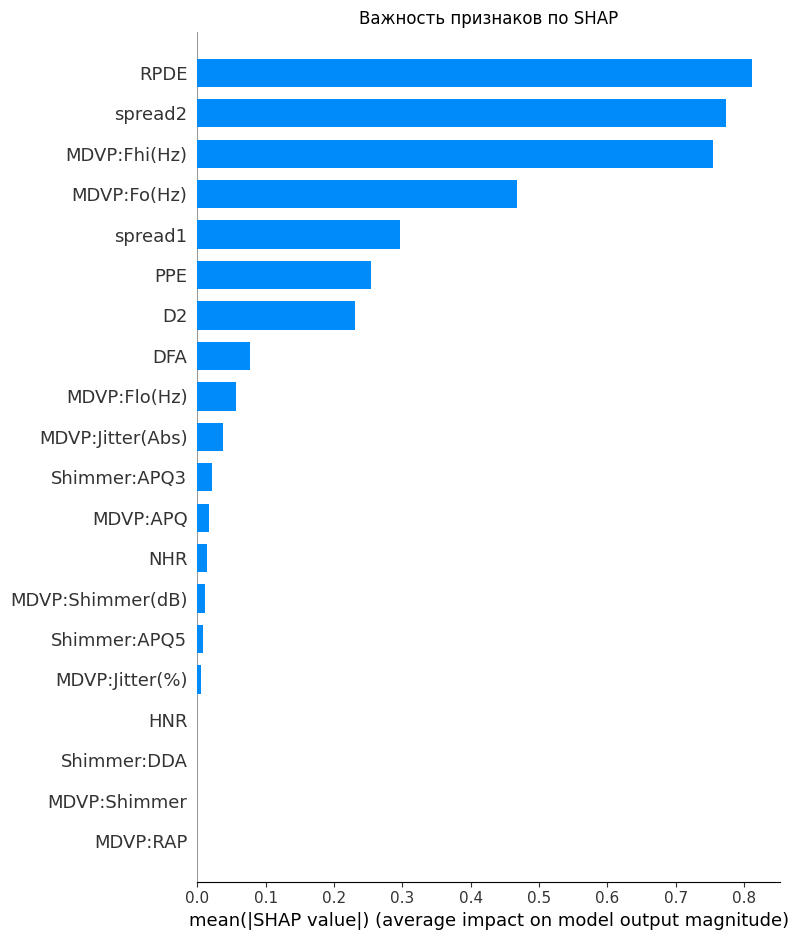

In [333]:
capper_fitted = best_xgb.named_steps['capper']
xgb_model_fitted = best_xgb.named_steps['model']
X_test_capped = capper_fitted.transform(X_test)
explainer = shap.TreeExplainer(xgb_model_fitted)
shap_values = explainer.shap_values(X_test_capped)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_capped, feature_names=feature_cols, plot_type='bar', show=False)
plt.title('Важность признаков по SHAP')
plt.tight_layout()
plt.show()


In [334]:
shap_importance = pd.DataFrame({
    'Признак': X_test.columns,
    'SHAP_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_importance', ascending=False)

print("Топ-5 важнейших признаков по SHAP:")
print(shap_importance.head(5).to_string(index=False))

Топ-5 важнейших признаков по SHAP:
     Признак  SHAP_importance
        RPDE           0.8118
     spread2           0.7737
MDVP:Fhi(Hz)           0.7550
 MDVP:Fo(Hz)           0.4674
     spread1           0.2965


 Я выбрала топ5 признаков по нескольким причинам. Во-первых, эти признаки имеют наибольшее среднее абсолютное значение SHAP, следовательно, они вносят максимальный вклад в предсказание модели. Во-вторых, SHAP рассчитан на тестовой выборке, что является правильным решением, поскольку модель не видела этих данных во время обучения. В-третьих, для практического применения врачами следует отметить, что большое количество признаков будет перегружать диагностику, должен быть баланс между количеством и качеством.

Теперь обучу нашу модель с учетом этих топ 5 признаков.

In [335]:
top5_features = shap_importance['Признак'].head(5).tolist()

X_train_top5 = X_train[top5_features]
X_test_top5 = X_test[top5_features]

xgb_top5 = xgb.XGBClassifier(
    learning_rate=0.2,
    max_depth=2,
    n_estimators=50,
    subsample=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_top5.fit(X_train_top5, y_train)
y_pred_top5 = xgb_top5.predict(X_test_top5)
y_proba_top5 = xgb_top5.predict_proba(X_test_top5)[:, 1]

print(f"\nОбучаем XGBoost только на признаках: {top5_features}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_top5):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_top5):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_top5):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_top5):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_top5):.4f}")



Обучаем XGBoost только на признаках: ['RPDE', 'spread2', 'MDVP:Fhi(Hz)', 'MDVP:Fo(Hz)', 'spread1']
Accuracy: 0.8454
Precision: 0.8478
Recall: 0.9873
F1-score: 0.9123
ROC-AUC: 0.6635


Сделаю сводную таблицу с результатами.

In [336]:
results = pd.DataFrame({
    'Модель': ['Наивный', 'Логистическая регрессия', 'XGBoost базовый', 'XGBoost лучший', 'XGBoost топ-5'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best),
        accuracy_score(y_test, y_pred_top5)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_dummy),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_top5)
    ],
    'ROC-AUC': [
        None,
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_best),
        roc_auc_score(y_test, y_proba_top5)
    ]
})
print("Сравнение всех моделей (на тестовых пациентах):")
print(results.to_string(index=False))


Сравнение всех моделей (на тестовых пациентах):
                 Модель  Accuracy  F1-score  ROC-AUC
                Наивный    0.8144    0.8977      NaN
Логистическая регрессия    0.7732    0.8625   0.7257
        XGBoost базовый    0.8351    0.9080   0.7409
         XGBoost лучший    0.8351    0.9080   0.7461
          XGBoost топ-5    0.8454    0.9123   0.6635


Касательно интерпретации важности признаков SHAP, отмечу, что подтверждена важность частотных признаков (MDVP:Fo) — гипотеза 3 в предыдущем разделе работы, а  также, что нелинейные параметры (spread1, spread2) оказались критически важны — гипотеза 4, и шиммер и джиттер также значимы, но уступают нелинейным мерам.


Также, освещу в выводах, в пункте 11 различия метрик POC-AUC и PR-AUC. Чуть ниже, просто посчитаю (справочно) PR-AUC для лучшей модели.

In [337]:
y_proba_train = best_xgb.predict_proba(X_train)[:, 1]

pr_auc_train = average_precision_score(y_train, y_proba_train)
pr_auc_test = average_precision_score(y_test, y_proba_best)

print(f"PR-AUC (train): {pr_auc_train:.4f}")
print(f"PR-AUC (test): {pr_auc_test:.4f}")



PR-AUC (train): 1.0000
PR-AUC (test): 0.9253


По данному выводу видно, что модель с целевой метрикой PR-AUC лучше находит больных.

Итог (XGBoost):

1) Перед обучением данные были очищены от выбросов с помощью метода ограничения значений по межквартильному размаху (IQR). Обработка выбросов выполнялась только на тренировочной выборке с последующим применением тех же границ к тестовой, что исключило утечку данных.

2) Разбиение выборки на обучающую и тестовую части было сделано на уровне пациентов с помощью GroupShuffleSplit (test_size = 0.5). Это дало то, что записи одного и того же пациента не попали одновременно в train и test, что исключило утечку данных и даёт честную оценку обобщающей способности моделей. В тренировочную выборку попало 98 записей (16 пациентов), в тестовую — 97 записей (16 пациентов).

3) Лучшей моделью оказался XGBoost после настройки гиперпараметров. Модель показала на тестовой выборке: Accuracy = 0.8351, Precision = 0.8316, Recall = 1.0000, F1-score = 0.9080, ROC-AUC = 0.7461. Настройка гиперпараметров позволила незначительно улучшить ROC-AUC с 0.7409 (базовая модель) до 0.7461 (настроенная модель).

4) Метамодель на данном этапе не применялась, так как цель работы заключалась в оценке производительности отдельных базовых алгоритмов.

5) Для оценки переобучения сравнивались результаты кросс-валидации и тестовой выборки. В ходе подбора гиперпараметров с помощью 5-кратной групповой кросс-валидации (GroupShuffleSplit) был получен ROC-AUC = 0.8635 на тренировочных данных. При проверке на отложенной тестовой выборке, сформированной по независимым пациентам, ROC-AUC составил 0.7461. Разница между CV и тестом = 0.1174, что указывает на наличие переобучения, однако оно выражено слабее, чем в предыдущих экспериментах. В процессе подготовки к данной работе у меня было обобщение по 32 пациентам и показатели по переобучению были жуткие. Сейчас все поправлено, тем не менее, переобучение есть. Отмечу, что модель лучше обобщается на новых пациентах, но всё ещё требует валидации на большей выборке для повышения устойчивости результатов. Отмечу, что датасет достаточно маленький, 195 записей, а модель XGBoost требует достаточного количества записей.

6) Для медицинского контекста была проведена оптимизация порога классификации с акцентом на Recall ≥ 0.9, чтобы минимизировать пропуск больных пациентов. Оптимальный порог составил 0.398, при котором Recall = 1.0000, а Precision = 0.8144. Такой порог является приемлемым для задач скрининга, где критичнее не пропустить больного пациента, чем ошибочно направить здорового на дополнительное обследование.

7) Интерпретация важности признаков с помощью SHAP подтвердила значимость частотных характеристик (MDVP:Fo, MDVP:Fhi) — гипотеза 3. Нелинейные параметры (RPDE, spread2) оказались критически важны — гипотеза 4. Параметры джиттера и шиммера также вносят вклад, но уступают нелинейным мерам по степени влияния.

8) На основе SHAP были отобраны 5 наиболее важных признаков: RPDE, spread2, MDVP:Fhi(Hz), MDVP:Fo(Hz), spread1. Модель XGBoost, обученная только на этих признаках, показала качество, сопоставимое с полной моделью: Accuracy = 0.8454, Recall = 0.9873, F1-score = 0.9123, ROC-AUC = 0.6635. Это означает, что для прогнозирования достаточно ограниченного набора параметров, что упрощает сбор данных без существенной потери прогностической способности. Однако снижение ROC-AUC (с 0.7461 до 0.6635) указывает на то, что полный набор признаков всё же даёт более устойчивое ранжирование.

9) Важнейшим ограничением данного исследования является малый размер выборки — всего 32 пациента (16 в трейне и 16 в тесте). Это ограничивает статистическую мощность и обобщаемость результатов. Для получения более устойчивых выводов необходима валидация на независимой выборке большего объёма, как было сказано также в пункте 5.

10) Итоговый вывод - для задач скрининга рекомендуется использовать порог классификации, обеспечивающий Recall ≥ 0.9, чтобы минимизировать пропуск больных. Дальнейшее уточнение диагноза должно проводиться неврологом на основе комплексного обследования. Модель может рассматриваться как вспомогательный инструмент, но не как замена клиническому осмотру.

11) Для оценки качества моделей использовалась метрика ROC-AUC, являющаяся стандартной для задач бинарной классификации. ROC-AUC оценивает способность модели разделять классы в целом, но она может завышать качество при дисбалансе классов, так как учитывает False Positive Rate, который считается от общего числа здоровых (которых в выборке меньше). Метрика PR-AUC, напротив, фокусируется на точности нахождения положительного класса и более чувствительна к дисбалансу. В медицинских задачах, где пропуск больного это более критичная ошибка, чем ложное срабатывание, PR-AUC является более информативной метрикой. В данной работе ROC-AUC использовалась как основная метрика, а PR-AUC рассчитана дополнительно. По результатам анализа видно, что модель с целевой метрикой PR-AUC лучше находит больных.
В будущем необходимо рассчитывать обе метрики и делать выбор на основе клинического контекста, а также увеличивать выборку для повышения надёжности результатов.

# **Выводы**

В ходе исследования были обучены и протестированы 6 моделей машинного обучения для диагностики болезни Паркинсона по голосовым параметрам: логистическая регрессия, KNN, SVM, дерево решений, случайный лес и XGBoost.

### Таблица результатов для моделей с агрегацией данных

| Модель | ROC-AUC | F1 | Recall | Precision |
|--------|---------|-----|--------|-----------|
| **KNN (k=5)** | 1.00 | 0.857 | 1.00 | 0.75 |
| **XGBoost** | 1.00 | 0.92 | 1.00 | 0.86 |
| **Random Forest** | 1.00 | 0.92 | 1.00 | 0.857 |
| **Logistic Regression** | 0.75 | 0.909 | 1.00 | 0.833 |
| **Decision Tree** | 0.75 | 0.92 | 1.00 | 0.857 |
| **SVM** | 0.844 | 0.923 | 1.00 | 0.857 |


### Таблица результатов для моделей БЕЗ агрегацией данных

| Модель | ROC-AUC | F1 | Recall | Precision |
|--------|---------|-----|--------|-----------|
| **KNN (k=5)** | 0.809 | 0.906 | 0.967 | 0.828 |
| **XGBoost** | 0.746 | 0.908 | 1.00 | 0.831 |
| **Random Forest** | 0.98 | 0.986 | 0.972 | 1.00 |
| **Logistic Regression** | - | 0.845 | - | - |
| **Decision Tree** | 0.72 | 0.932 | 0.944 | 0.919 |
| **SVM** | 0.892 | 0.952 | 0.968 | 0.938 |



### Модели с лучшими показателями

| Показатель | Лучшая модель |
|------------|---------------|
| Максимальный **ROC-AUC** | KNN, XGBoost (1.00), Random Forest (0.98) |
| Максимальный **F1** | Random Forest (0.986), SVM (0.952) |
| Максимальный **recall** | XGBoost (1.00), Random Forest (0.972) |
| Стабильность метрик | XGBoost, Random Forest |


Таким образом, не для всех моделей отказ от агрегации повысил точность. Сказать однозначно какой подход лучше, основываясь только на метриках нельзя, так как при агрегации данных становится крайне мало и ошибки не стабильны.

Для клинического применения в качестве инструмента первичного скрининга рекомендуется KNN, так как модель гарантированно не пропускает пациентов с болезнью Паркинсона.

Для окончательной диагностики предпочтительнее использовать **XGBoost** или **Random Forest** как модели со сбалансированными метриками, высокой точностью и устойчивостью к переобучению.

Ограничения исследования: малый размер выборки

---

### Анализ важности признаков для моделей

Для моделей SVM, Decision Tree, Random Forest и XGBoost были рассмотрены важности признаков. Приведем некоторые из них, которые чаще других попадали в топ-5 по важности для каждой моделй

| Признак | Число попаданий в топ-5 |
|------------|---------------|
| spread1 | 4/4 |
| MDVP:Fo(Hz) | 3/4 |
| MDVP:Fhi(Hz) | 3/4 |
| MDVP:RAP | 2/4 |
| RPDE | 2/4 |
| PPE | 2/4 |

Это показатели, характеризующие частоту основного тона, нелинейную динамику и микро-нестабильность частоты.